# Solutions · 07 · Smoothing noisy signals

Worked solutions to the exercises of [notebook 07](../notebooks/07_smoothing.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import smoothing
x = np.linspace(0, 20, 401); dx = x[1] - x[0]
def peak(x, h, c, w): return h*np.exp(-0.5*((x - c)/w)**2)
true = peak(x, 1.0, 8.0, 0.8) + peak(x, 0.6, 10.5, 1.0) + 0.05
y = true + np.random.default_rng(7).normal(0, 0.05, x.size)

## Exercise 1

Add a single spike (an electrical glitch) to the signal. Compare `lowess` with and without
   `robust_iters=2`.

max error near the spike: plain LOWESS 0.172, robust LOWESS 0.021


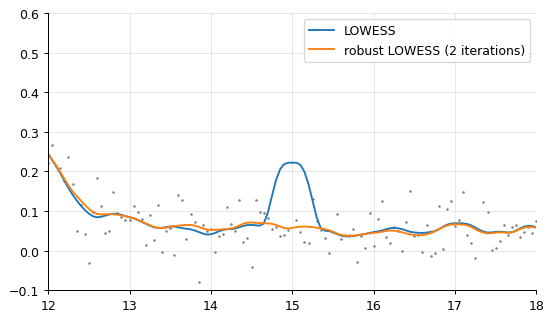

In [2]:
y_spike = y.copy(); y_spike[300] += 1.5                     # glitch at x = 15
plain = smoothing.lowess(x, y_spike, 0.04)
robust = smoothing.lowess(x, y_spike, 0.04, robust_iters=2)
near = np.abs(x - 15) < 1.0
print(f"max error near the spike: plain LOWESS {np.max(np.abs(plain - true)[near]):.3f}, "
      f"robust LOWESS {np.max(np.abs(robust - true)[near]):.3f}")
plt.plot(x, y_spike, ".", ms=2, color="gray"); plt.plot(x, plain, label="LOWESS")
plt.plot(x, robust, label="robust LOWESS (2 iterations)"); plt.xlim(12, 18); plt.ylim(-0.1, 0.6); plt.legend(); plt.show()

Plain LOWESS spreads the glitch into a bump several points wide. The robust iterations give the spike a
weight near zero after the first pass, so the smoothed curve ignores it - robust methods flag outliers
instead of averaging them in.

## Exercise 2

Use the second derivative (`deriv=2`) to detect the shoulder of the smaller peak. Why is the
   second derivative even more sensitive to the window size?

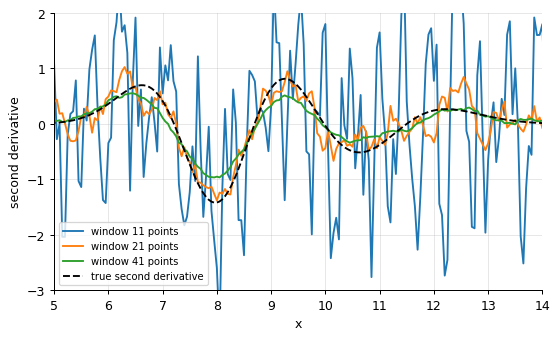

In [3]:
fig, ax = plt.subplots()
for m in (5, 10, 20):
    d2 = smoothing.savitzky_golay(y, m, 3, deriv=2, dx=dx)
    ax.plot(x, d2, label=f"window {2*m + 1} points")
ax.plot(x, np.gradient(np.gradient(true, dx), dx), "k--", label="true second derivative")
ax.set(xlim=(5, 14), ylim=(-3, 2), xlabel="x", ylabel="second derivative"); ax.legend(fontsize=8); plt.show()

A peak shows up as a **minimum** of the second derivative; the shoulder of the smaller peak becomes a
separate minimum near $x$ = 10.5 even though the signal itself has no separate maximum there. With an
11-point window the noise swamps everything; with 41 points both minima survive but become shallower
and broader (the main one loses about a third of its depth) - larger windows still would merge them.
Each differentiation
multiplies the noise by roughly $1/h$ - the second derivative by $1/h^2$ - so it needs more smoothing,
and that smoothing distorts the very features we look for.

## Exercise 3

Show that a Savitzky-Golay filter of order 2 with a 5-point window reproduces any quadratic
   exactly. Why does that make it suitable for smooth physical signals?

In [4]:
xs = np.arange(30.0)
quadratic = 0.3*xs**2 - 2*xs + 7
print("max |SG(quadratic) - quadratic| =", np.max(np.abs(smoothing.savitzky_golay(quadratic, 2, 2) - quadratic)))

max |SG(quadratic) - quadratic| = 5.684341886080802e-14


The filter fits a quadratic by least squares in each 5-point window; if the data *are* a quadratic, the
fit is exact and returns the data unchanged. Smooth physical signals look locally like low-order
polynomials, so the filter passes them almost untouched while averaging away noise - unlike a moving
average, which fits a constant and flattens every peak.

## Exercise 4

**Implement it yourself:** write `exponential_smoothing(y, a)` with $s_i = a\,y_i + (1 - a)\,s_{i-1}$, the filter used in many real-time instruments. Apply it to the peaks. Why does it shift them to later times, unlike the centred filters?

true peak at x = 8.05
a = 0.5 : peak at x = 8.10, delay 0.05 (theory (1-a)/a samples = 0.05), height 1.074 (true 1.078)
a = 0.2 : peak at x = 8.25, delay 0.20 (theory (1-a)/a samples = 0.20), height 1.046 (true 1.078)
a = 0.1 : peak at x = 8.45, delay 0.40 (theory (1-a)/a samples = 0.45), height 0.971 (true 1.078)
a = 0.05: peak at x = 8.75, delay 0.70 (theory (1-a)/a samples = 0.95), height 0.823 (true 1.078)


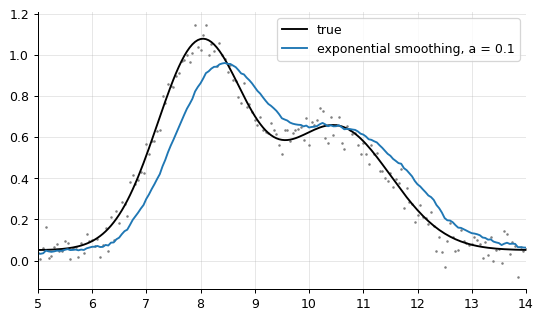

In [5]:
def exponential_smoothing(y, a):
    s = np.empty_like(y); s[0] = y[0]
    for i in range(1, y.size):
        s[i] = a*y[i] + (1 - a)*s[i-1]
    return s

x_peak = x[np.argmax(true)]
print(f"true peak at x = {x_peak:.2f}")
for a in (0.5, 0.2, 0.1, 0.05):
    s = exponential_smoothing(true, a)            # noise-free signal: the delay is not blurred by noise
    print(f"a = {a:<4}: peak at x = {x[np.argmax(s)]:.2f}, delay {x[np.argmax(s)] - x_peak:.2f} "
          f"(theory (1-a)/a samples = {(1 - a)/a*dx:.2f}), height {s.max():.3f} (true {true.max():.3f})")
plt.plot(x, y, ".", ms=2, color="gray"); plt.plot(x, true, "k", label="true")
plt.plot(x, exponential_smoothing(y, 0.1), label="exponential smoothing, a = 0.1")
plt.xlim(5, 14); plt.legend(); plt.show()

Exponential smoothing uses only past values - it can run in real time, sample by sample, which is why
instruments use it. The price is a **delay**: the output lags the signal by about $(1 - a)/a$ samples, so
peaks appear later (and lower). Centred filters (moving average, Savitzky-Golay, LOWESS) need future
samples and have no lag, which is fine for recorded data. (For strong smoothing of a narrow peak the
measured delay is somewhat below $(1 - a)/a$, a rule derived for slowly varying signals - and the peak is
also much lower.)